# Coherence measurements using speckle
awojdyla@lbl.gov, Jan 2026

We would like to use speckle to probe the coherence of x-ray beams.

It turns out that when light scatters coherently through a random media, the Fourier spectum of the speckle pattern collected downstream has some rings, that are rings in the spectrum, that correspond to the Talbot distance for a specific spatial wavelength
(see poster https://drive.google.com/file/d/1RSC3LrxQJxj8N_iXHwJ4T0EOFNPHRG_Y/view?usp=sharing)

We have in the past demonstrated that these rings can encode the distance relatively precisely when using a visible beam. In this notebook, we would like to show that we can use this technique in the soft x-ray regime, and that we can use it to probe the coherence of the beam, as the rings will blur out with source size.

This notebook is mostly based on the work of Mahmoud Morsy, a SULI student at the ALS in 2020 (Project Supreme: https://github.com/mmorst/Supreme/blob/master/01_Generate_data.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# useful functions for processing FFT and speckle patterns
## borrorwed from https://github.com/mmorst/Supreme/blob/master/supreme.py

from skimage.transform import warp, warp_polar

# zero centered FFT and IFFT
def ft(t):
    return np.fft.fftshift( np.fft.fft2(np.fft.ifftshift(t)))

def ift(t):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(t)))

# frequency axis for FFT
def fs(t):
    N = len(t)
    df_cpm = 1/(t[-1]-t[0])
    f_cpm = np.fft.fftshift(np.array([df_cpm*n if n<N/2 else df_cpm*(n-N) for n in range(N)]))
    return f_cpm

# Fourier optics transfer function propagation
def propTF(E_in,L_m,lambda_m,z_m):
    #get input field array size
    (Nx, Ny)=np.shape(E_in); 
    dx=L_m/Nx; #sample interval

    #(dx<lambda.*z/L)

    fx = fs(np.arange(Nx)*dx)
    if Ny>2:
        fy = fs(np.arange(Ny)*dx)
    else:
        fy = 0

    [FX,FY]= np.meshgrid(fx,fy)

    H=np.exp(-1j*np.pi*lambda_m*z_m*(FX**2+FY**2))

    E_out = ft(ft(E_in)*H)
    
    return E_out

def gaussian(x_px, mean_px, fwhm_px):
    '''
    GAUSSIAN Returns a 1D gaussian
    gaussian(x_px, mean_px, fwhm_px)
    :param x_px: numpy array
    :param mean_px: double
    :param fwhm_px: double
    :return: numpy array
    '''
    sigma_x = fwhm_px/(2*np.sqrt(2*np.log(2)));
    return np.exp(-((x_px-mean_px)/(np.sqrt(2)*sigma_x))**2)
        
def generate_speckle(dx_m, Dx_m, z_m, fhwm_m=500e-6, lambda_m=1e-6, fc_cpm =1e6, wfe_w=1/20):
    '''GENERATE_SPECKLE
    generate_speckle(dx_m, Dx_m, z_m, lambda_m=1e-6, fc_cpm =1e6, wfe_w=1/20)
    :param dx_m: double
    :param Dx_m: double
    :param z_m: double
    :param lambda_m: double
    :param fc_cpm: double
    :param wfe_w: double
    :return: numpy array
    '''

    # define spatial axis
    x_m = np.linspace(-Dx_m/2,Dx_m/2,int(np.ceil(Dx_m/dx_m)))
    N = len(x_m)

    (X_m,Y_m) = np.meshgrid(x_m,x_m);
    # define frequency axis
    f_cpm = fs(x_m)
    (Fx, Fy) = np.meshgrid(f_cpm,f_cpm);

    # frequency filter
    GFILT = gaussian(Fx, 0, fc_cpm)*gaussian(Fy, 0, fc_cpm);

    # generation of speckle and propagations
    noise = np.random.randn(N,N)
    noise_filt = np.abs(ift(ft(noise)*GFILT));
    noise_filt = noise_filt/np.std(noise_filt);

    # generate laser beam
    E0 = gaussian(X_m, 0, fhwm_m)*gaussian(Y_m, 0, fhwm_m);
    # add speckle to beam
    E1 = E0*np.exp(1j*2*np.pi*noise_filt*wfe_w);

    # propagation
    E2 = propTF(E1,Dx_m,lambda_m,z_m);
    I = np.abs(E2)**2
    return I
 
def azimuthal_avg(data_2d):
    '''
    AZIMUTHAL_AVG Azimuthal average of a 2D square image
    azimuthal_avg(data_2d)
    :param data_2d: square 2D numpy array
    :return: numpy 1D array
    '''
    Np = int(np.floor((len(data_2d)+1)/2))
    azimuthal_avg = np.sum(warp_polar(data_2d), 0)
    return azimuthal_avg[0:(Np-1)]

In [3]:
# wavelenth
wavelength_m = 10e-9 #(10nm~125 eV))
# propagation distance
z_m = 30e-3
# pixel size
dx_m = 1e-6
# screen size
Dx_m = 2e-3-dx_m/2

# create a spatial axis (important for computations)
x_m = np.linspace(-Dx_m/2, Dx_m/2, int(np.floor(Dx_m/dx_m)))

img = generate_speckle(dx_m, Dx_m, z_m, fhwm_m=1e-3, lambda_m=10e-9, fc_cpm =1e6, wfe_w=1/20)

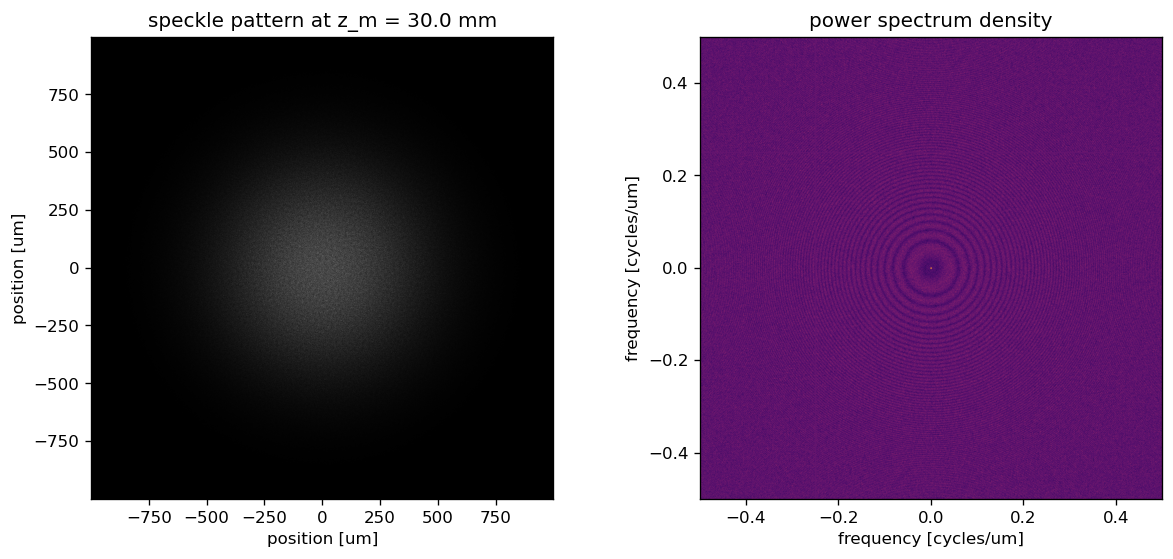

In [4]:
# take the Fourier Transform
IMG = ft(img)

# removing zero frequencies (tend to dominate the signal), but just for display
IMG_d = IMG
IMG_d[498:503,:]=np.mean(abs(IMG))
IMG_d[:,498:503]=np.mean(abs(IMG))

# corresponding frequency scale
f_cpm = fs(x_m)

# scale the plot
Df_cpm = f_cpm[-1]-f_cpm[0]
extent = (-Df_cpm/2 * 1e-6, +Df_cpm/2 * 1e-6, -Df_cpm/2 * 1e-6, +Df_cpm/2 * 1e-6) 

fig=plt.figure(figsize=(12, 5), dpi= 120, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)

plt.imshow(img, extent=(-Dx_m/2*1e6, Dx_m/2*1e6, -Dx_m/2*1e6, Dx_m/2*1e6), cmap = 'gray')
plt.title('speckle pattern at z_m = %1.1f mm' % (z_m*1e3))
plt.xlabel('position [um]')
plt.ylabel('position [um]')

plt.subplot(1, 2, 2)
plt.imshow(np.abs(IMG_d)**0.1, extent=extent, cmap = 'inferno')
plt.title('power spectrum density')
plt.xlabel('frequency [cycles/um]')
plt.ylabel('frequency [cycles/um]')
plt.show()

## Analysis of the rings

In [5]:
#TBD

## Adding coherence fraction
We are going to do a sum of coherent source

In [6]:
#TBD

# Simulation a RZP

In [7]:
#TBD